<a href="https://colab.research.google.com/github/oliver-morris/Dictionary-Language-Model/blob/main/Research/NeuralNetworkBasics/NeuralNetwork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Understanding the basic neural network library by creating my own

Potential improvements:
- neuroplasticity: the ability to form new connections, strengthen and weaken synapses and generate new neurons (helps with learning and memory)

# Basic Neural Network

From GeeksforGeeks
https://www.geeksforgeeks.org/numpy/implementation-of-neural-network-from-scratch-using-numpy/

In [1]:
import numpy as np

In [2]:
# Creating data set

# A
a =[0, 0, 1, 1, 0, 0,
   0, 1, 0, 0, 1, 0,
   1, 1, 1, 1, 1, 1,
   1, 0, 0, 0, 0, 1,
   1, 0, 0, 0, 0, 1]
# B
b =[0, 1, 1, 1, 1, 0,
   0, 1, 0, 0, 1, 0,
   0, 1, 1, 1, 1, 0,
   0, 1, 0, 0, 1, 0,
   0, 1, 1, 1, 1, 0]
# C
c =[0, 1, 1, 1, 1, 0,
   0, 1, 0, 0, 0, 0,
   0, 1, 0, 0, 0, 0,
   0, 1, 0, 0, 0, 0,
   0, 1, 1, 1, 1, 0]

# Creating labels
y =[[1, 0, 0],
   [0, 1, 0],
   [0, 0, 1]]

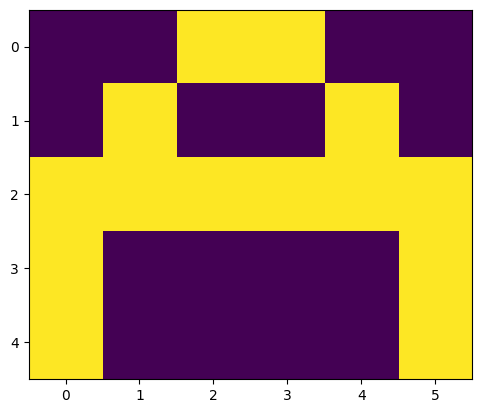

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# visualizing the data, plotting A.
plt.imshow(np.array(a).reshape(5, 6))
plt.show()

In [4]:
# converting data and labels into numpy array
x =[np.array(a).reshape(1, 30), np.array(b).reshape(1, 30),
                                np.array(c).reshape(1, 30)]
y = np.array(y)
# Printing data and labels
print(x, "\n\n", y)

[array([[0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
        0, 1, 1, 0, 0, 0, 0, 1]]), array([[0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0,
        1, 0, 0, 1, 1, 1, 1, 0]]), array([[0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
        0, 0, 0, 1, 1, 1, 1, 0]])] 

 [[1 0 0]
 [0 1 0]
 [0 0 1]]


In [5]:
# activation function
def sigmoid(x):
	return(1/(1 + np.exp(-x)))

# Creating the Feed forward neural network
def f_forward(x, w1, w2):
	# hidden
	z1 = x.dot(w1)    # input from layer 1
	a1 = sigmoid(z1)  # out put of layer 2
	z2 = a1.dot(w2)   # input of out layer
	a2 = sigmoid(z2)  # output of out layer
	return(a2)

# initializing the weights randomly
def generate_wt(x, y):
	li =[]
	for i in range(x * y):
		li.append(np.random.randn())
	return(np.array(li).reshape(x, y))

# for loss we will be using mean square error(MSE)
def loss(out, Y):
	s =(np.square(out-Y))
	s = np.sum(s)/len(y)
	return(s)

# Back propagation of error
def back_prop(x, y, w1, w2, alpha):

	# hidden layer
	z1 = x.dot(w1)
	a1 = sigmoid(z1)
	z2 = a1.dot(w2)
	a2 = sigmoid(z2)

	# error in output layer
	d2 =(a2-y)
	d1 = np.multiply((w2.dot((d2.transpose()))).transpose(),
								(np.multiply(a1, 1-a1)))
	# Gradient for w1 and w2
	w1_adj = x.transpose().dot(d1)
	w2_adj = a1.transpose().dot(d2)

	# Updating parameters
	w1 = w1-(alpha*(w1_adj))
	w2 = w2-(alpha*(w2_adj))

	return(w1, w2)

In [6]:
w1 = generate_wt(30, 5)
w2 = generate_wt(5, 3)

print(w1, "\n\n", w2)

[[ 0.79449626 -1.29872082 -2.21630092  0.09569512  1.12376982]
 [-1.93599669 -0.82320943 -0.1419728  -0.05299974 -0.25083199]
 [-0.07387979 -0.15366248  0.32955333  0.89969439 -2.03957653]
 [-0.37936656  0.04378649 -0.31706841  0.6756639  -1.52268963]
 [ 0.82169086  0.8435342   0.40362526  1.16456309  1.01566109]
 [ 0.40568172 -0.86199255  0.59818951 -0.84511824 -0.06604456]
 [-2.83955143 -0.35692049  1.04564406  0.10840774 -1.77541877]
 [ 0.04356259 -0.83808929  0.43869266  1.80626513 -1.27082536]
 [-1.35959382 -1.7598793  -0.30342967 -0.75753745 -0.27924031]
 [ 0.59489991  0.12588794 -0.32331831 -0.18289371  0.03993166]
 [-1.34716892  0.29413091 -0.13722217  1.32916897 -0.08380957]
 [-1.18906479  0.67454539  0.91223462  0.16325193 -1.86456128]
 [ 0.53879714  0.69066252  0.41725031  0.72825159  0.16137676]
 [-0.41787726 -0.24751068  0.05592348  1.21541615  0.2673716 ]
 [-0.1002134   1.28866945 -0.09440803 -1.60795243 -1.41478465]
 [-0.97053242 -0.3305521   0.4002678   1.11697709 -0.49

In [7]:
def train(x, Y, w1, w2, alpha = 0.01, epoch = 10):
	acc =[]
	losss =[]
	for j in range(epoch):
		l =[]
		for i in range(len(x)):
			out = f_forward(x[i], w1, w2)
			l.append((loss(out, Y[i])))
			w1, w2 = back_prop(x[i], y[i], w1, w2, alpha)
		print("epochs:", j + 1, "======== acc:", (1-(sum(l)/len(x)))*100)
		acc.append((1-(sum(l)/len(x)))*100)
		losss.append(sum(l)/len(x))
	return(acc, losss, w1, w2)

acc, losss, w1, w2 = train(x, y, w1, w2, 0.1, 100)

epochs: 1 ======== acc: 64.80386395798025
epochs: 2 ======== acc: 66.6008571113111
epochs: 3 ======== acc: 68.59782106034065
epochs: 4 ======== acc: 70.70867791994355
epochs: 5 ======== acc: 72.80262730523236
epochs: 6 ======== acc: 74.74392378526609
epochs: 7 ======== acc: 76.43493717129427
epochs: 8 ======== acc: 77.83720942272944
epochs: 9 ======== acc: 78.96419978922715
epochs: 10 ======== acc: 79.8591769105321
epochs: 11 ======== acc: 80.574127389131
epochs: 12 ======== acc: 81.1568050922291
epochs: 13 ======== acc: 81.64547265532994
epochs: 14 ======== acc: 82.06831171688103
epochs: 15 ======== acc: 82.44489395240844
epochs: 16 ======== acc: 82.78821090683677
epochs: 17 ======== acc: 83.10658968505484
epochs: 18 ======== acc: 83.40526024988618
epochs: 19 ======== acc: 83.68753035922647
epochs: 20 ======== acc: 83.95559981396107
epochs: 21 ======== acc: 84.21107753573602
epochs: 22 ======== acc: 84.45527751969509
epochs: 23 ======== acc: 84.68936794462678
epochs: 24 ======== acc: 

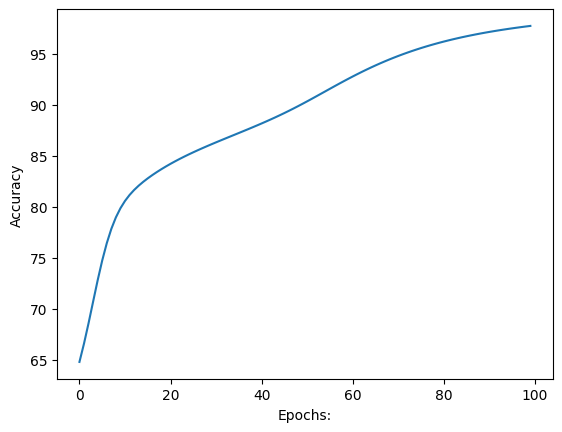

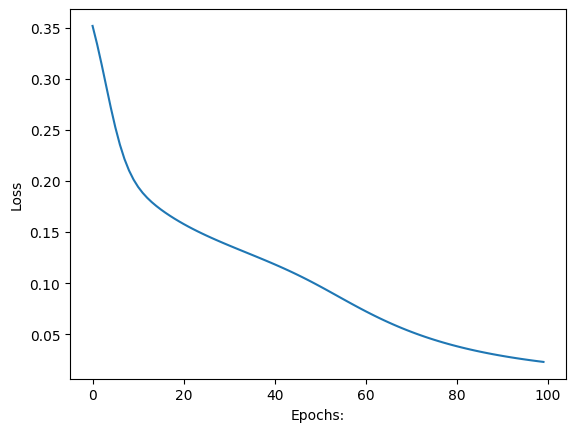

In [9]:
# plotting accuracy
plt.plot(acc)
plt.ylabel('Accuracy')
plt.xlabel("Epochs:")
plt.show()

# plotting Loss
plt.plot(losss)
plt.ylabel('Loss')
plt.xlabel("Epochs:")
plt.show()

Image is of letter B.


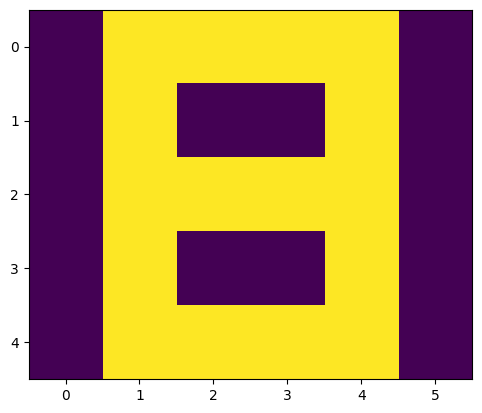

In [14]:
def predict(x, w1, w2):
	Out = f_forward(x, w1, w2)
	maxm = 0
	k = 0
	for i in range(len(Out[0])):
		if(maxm<Out[0][i]):
			maxm = Out[0][i]
			k = i
	if(k == 0):
		print("Image is of letter A.")
	elif(k == 1):
		print("Image is of letter B.")
	else:
		print("Image is of letter C.")
	plt.imshow(x.reshape(5, 6))
	plt.show()
# Example: Predicting for letter 'B'
predict(x[1], w1, w2)